In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")

In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
data = np.array(data)
m, n = data.shape

np.random.shuffle(data)

data_dev = data[0:1000].T
y_dev = data_dev[0]
x_dev = data_dev[1:n]
x_dev = x_dev/255

data_train = data[1000:m].T
y_train = data_train[0]
x_train = data_train[1:n]
x_train = x_train/255

In [7]:
x_train[:,0].shape

(784,)

In [23]:
def init_params():
    w1 = np.random.rand(10,784)-0.5
    b1 = np.random.rand(10,1)-0.5
    w2 = np.random.rand(10,10)-0.5
    b2 = np.random.rand(10,1)-0.5
    return w1,b1,w2,b2

In [13]:
def relU(z):
    return np.maximum(0,z)

def DrelU(z):
    return z > 0

In [32]:
def softMax(z):
    A = np.exp(z - np.max(z, axis=0, keepdims=True))
    return A / np.sum(A, axis=0, keepdims=True)

In [16]:
def forward_prop(w1,b1,w2,b2,X):
    z1 = w1.dot(X)+b1
    a1 = relU(z1)
    z2 = w2.dot(a1)+b2
    a2 = softMax(z2)
    return z1,a1,z2,a2

In [12]:
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size),Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [29]:
def back_prop(z1,a1,z2,a2,w2,X,Y):
    m = Y.size
    one_hot_y = one_hot(Y)
    dZ2 = a2 - one_hot_y
    dW2 = 1/m * dZ2.dot(a1.T)
    db2 = 1/m * np.sum(dZ2)
    dZ1 = w2.T.dot(dZ2) * DrelU(z1)
    dW1 = 1/m * dZ1.dot(X.T)
    db1 = 1/m * np.sum(dZ1)
    return dW1, db1, dW2, db2

In [15]:
def update_params(w1,b1,w2,b2,dW1,db1,dW2,db2,alpha):
    w1 = w1 - alpha * dW1
    w2 = w2 - alpha * dW2
    b1 = b1 - alpha * db1
    b2 = b2 - alpha * db2
    return w1, b1, w2, b2

In [18]:
def get_predictions(a2):
    return np.argmax(a2,0)

In [19]:
def get_accuracy(predictions,Y):
    print(predictions,Y)
    return np.sum(predictions==Y)/Y.size

In [40]:
def gradient_descent(X,Y,iterations,alpha):
    w1,b1,w2,b2 = init_params()
    for i in range(iterations):
        z1,a1,z2,a2 = forward_prop(w1,b1,w2,b2,X)
        dw1,db1,dw2,db2 = back_prop(z1,a1,z2,a2,w2,X,Y)
        w1,b1,w2,b2 = update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha)
        if i % 50 == 0:
            print("Iteration :",i)
            print("Accuracy :",get_accuracy(get_predictions(a2),Y))
    return w1,b1,w2,b2

In [41]:
w1,b1,w2,b2 = gradient_descent(x_train,y_train,500,0.1)

Iteration : 0
[4 5 9 ... 9 5 5] [9 3 2 ... 7 5 7]
Accuracy : 0.09965853658536586
Iteration : 50
[4 8 7 ... 1 7 7] [9 3 2 ... 7 5 7]
Accuracy : 0.5377317073170732
Iteration : 100
[4 5 7 ... 8 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.6786585365853659
Iteration : 150
[9 5 7 ... 8 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.7383170731707317
Iteration : 200
[9 5 7 ... 8 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.7708048780487805
Iteration : 250
[9 5 7 ... 8 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.7941219512195122
Iteration : 300
[9 5 7 ... 8 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.811439024390244
Iteration : 350
[9 5 7 ... 3 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.8243414634146341
Iteration : 400
[9 5 7 ... 3 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.8354878048780487
Iteration : 450
[9 5 7 ... 3 5 7] [9 3 2 ... 7 5 7]
Accuracy : 0.843609756097561


In [45]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = x_train[:, index, None]
    prediction = make_predictions(x_train[:, index, None], W1, b1, W2, b2)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [9]
Label:  9


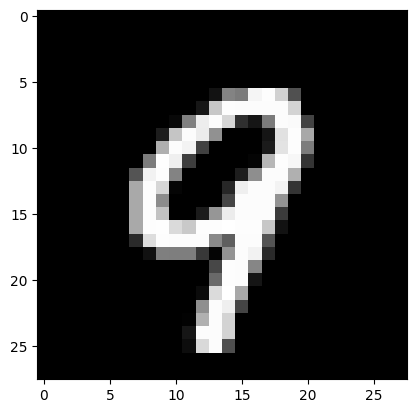

Prediction:  [3]
Label:  3


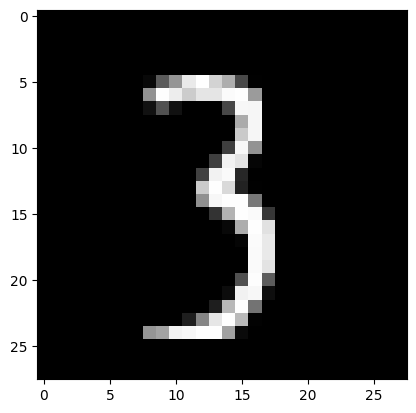

Prediction:  [9]
Label:  9


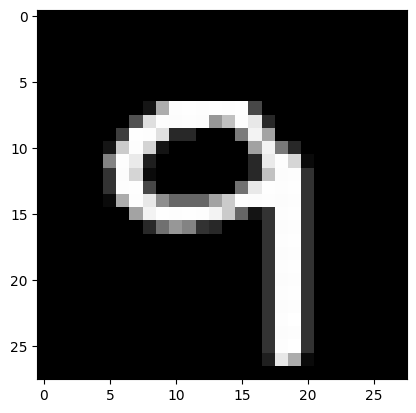

Prediction:  [1]
Label:  1


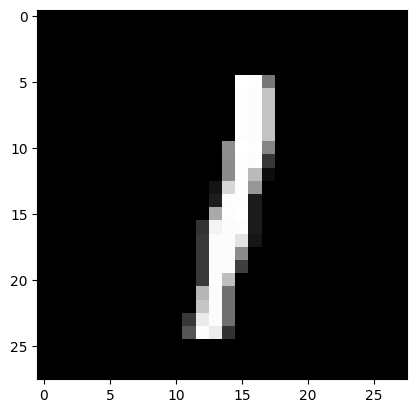

In [47]:
test_prediction(0, w1, b1, w2, b2)
test_prediction(4, w1, b1, w2, b2)
test_prediction(6, w1, b1, w2, b2)
test_prediction(8, w1, b1, w2, b2)

In [50]:
dev_predictions = make_predictions(x_dev, w1, b1, w2, b2)
get_accuracy(dev_predictions, y_dev)

[1 9 3 3 2 8 4 6 8 4 1 1 1 6 5 6 5 4 1 8 6 4 6 4 7 5 3 9 4 2 4 3 4 6 4 5 7
 6 2 0 3 3 5 8 7 0 1 2 6 1 7 5 7 8 0 1 1 7 0 9 4 6 9 2 3 5 0 2 3 4 3 5 4 0
 6 9 9 4 2 1 7 6 9 3 7 0 2 2 2 6 1 0 1 1 8 0 1 0 4 6 4 1 0 2 3 6 9 9 6 7 9
 2 6 8 7 1 9 1 1 1 7 9 3 6 7 6 9 3 8 5 2 7 0 8 5 4 1 2 5 0 9 8 6 9 7 1 2 7
 1 3 1 6 9 7 5 8 1 7 9 8 8 9 9 0 3 9 5 0 7 1 6 9 5 5 2 9 8 4 8 0 8 3 8 4 2
 5 0 1 4 7 9 7 2 1 1 0 4 6 1 1 0 3 7 0 5 8 3 0 7 9 0 7 3 8 4 8 1 2 6 5 1 5
 5 8 9 3 1 5 2 1 3 3 2 0 5 0 6 9 3 7 6 7 8 7 3 7 3 1 1 0 7 5 4 4 1 7 3 2 5
 9 1 5 4 0 9 1 6 2 8 0 2 0 8 9 0 6 7 2 1 3 9 0 0 3 0 2 8 1 8 2 5 8 6 5 3 6
 4 6 1 0 4 8 9 8 9 0 0 8 8 1 4 6 7 1 5 0 7 5 8 2 2 1 5 9 1 6 2 4 8 3 6 3 5
 3 3 6 4 7 3 2 6 4 5 2 0 9 2 8 8 1 1 5 0 7 8 2 4 9 2 2 9 8 2 5 6 9 0 7 8 5
 8 7 2 9 4 8 8 8 4 1 5 7 0 8 6 2 7 2 6 3 4 5 1 4 3 4 9 6 9 8 6 7 1 6 1 8 3
 6 8 7 1 7 9 5 3 8 4 6 7 6 8 8 1 0 8 2 7 0 3 7 7 2 5 6 1 6 8 0 7 3 2 0 1 5
 3 5 6 4 1 2 5 2 5 3 8 9 2 7 1 8 6 0 2 6 0 5 7 3 4 4 4 8 8 4 7 1 5 1 0 1 0
 9 1 1 2 9 9 9 6 7 1 5 7 

np.float64(0.846)